##Linear Regression From Scratch (NumPy)

This is implementation of Linear Regression from scratch using only NumPy.

Goal: To understand what actually happens behind libraries like Scikit-learn instead of just calling built-in functions.

#Implementation Flow

1. Generate/load data (X, y)         — get something concrete to work with
2. Inspect shapes                     — N samples, d features — Topic 4 vocabulary, made real
3. Initialize w, b                    — random or zero starting knobs
4. Forward pass                       — compute ŷ = wx + b for all samples at once
5. Compute loss (MSE)                 — one number: how wrong are we, overall?
6. Compute gradients                  — which direction should w, b move?
7. Update w, b                        — the actual "nudge," done by a formula now, not by hand
8. Repeat steps 4-7 many times        — training loop / epochs
9. Plot loss over time                — did it actually learn?
10. Plot the fitted line              — does it visually make sense?
11. Compare to sklearn                — verify our from-scratch numbers match a trusted library

Load Library

In [16]:
import numpy as np

## 1.Generate Dataset

In [17]:
X= 0.5 + 3 * np.random.rand(50,1) #1 feature 1000 sqft unit ,rand value between 0.5 and 3.5
#range 0.5 - 3.5

noise = np.random.randn(50,1) * 5   #randn -+ve or -ve around zeros
y= 50 * X + 20 +noise #pattern as ml learns real relations not random data

#added noise to get different outputs for same X  - not alwasy straight line should be there



In [18]:
X

array([[2.09565508],
       [3.36433208],
       [1.23426559],
       [1.05408514],
       [1.76556002],
       [1.38112704],
       [1.49846193],
       [1.02344578],
       [0.60708656],
       [3.00888063],
       [1.34497427],
       [2.85317759],
       [1.7103696 ],
       [2.82608356],
       [1.68213234],
       [1.74194133],
       [2.593931  ],
       [1.37163412],
       [1.90033533],
       [2.61213164],
       [2.60305897],
       [1.44513154],
       [1.59870212],
       [2.68297573],
       [1.06067846],
       [1.18666673],
       [1.19391432],
       [2.1025422 ],
       [1.64814934],
       [2.05010796],
       [1.36817313],
       [1.03643727],
       [2.71745455],
       [2.54847653],
       [2.57674898],
       [1.64064169],
       [2.19201352],
       [0.56560948],
       [2.47348875],
       [3.01940586],
       [0.88385277],
       [3.02507169],
       [1.00268257],
       [0.51523418],
       [0.96341732],
       [3.15433675],
       [1.97995319],
       [2.249

2.Shapes

In [19]:
print(X.shape)
print(y.shape)

(50, 1)
(50, 1)


3.initialize parameters

y = wx+b

In [20]:
w= 0.0
b= 0.0

4.forward pass
y_pred = X * w + b

In [21]:
y_pred = X*w +b

In [22]:
print(y_pred[:5])


[[0.]
 [0.]
 [0.]
 [0.]
 [0.]]


Both w and b are 0 so so every pred is also zero model hasn't learned yet

4.Loss Fun MSE  1/2m summation (y_pred - y ) ^2

In [23]:
def compute_mse(y_pred,y):
  return np.mean( (y_pred - y)**2) /2


In [24]:
loss = compute_mse(y_pred,y)
print(loss)

#6781.00364390157 it is starting loss before any training happens
#not error of bad model - Error of mode that has not learned anything yet

7226.920103764958


5.Compute gradient - tells how much w and b should change to reduce loss

In [25]:
db = np.mean(y_pred - y )
dw=  np.mean((y_pred - y ) * X)
print(db)
print(dw)



-114.02804943473829
-243.5501821230776


update w and b
a = 0.01

In [26]:
a =0.01 #learning rate - controls how big each update step should be

temp_b = b - a*db
temp_w = w - a*dw

b= temp_b
w= temp_w

print(b)
print(w)

1.140280494347383
2.435501821230776


#gd loop
1.forward pass y_pred computation
2.MSE calculation
3. gradients dw and db  calulation

4.update  w and b

In [27]:
w= 0.0
b= 0.0

alpha = 0.01
epochs = 1000

loss_history = []

for epoch in range(epochs):
  #1.forward pass
  y_pred = X*w +b
  #2.compute MSE
  Loss = compute_mse(y_pred,y)
  loss_history.append(Loss)
  #3.gradient db dw
  db = np.mean(y_pred - y)
  dw = np.mean((y_pred-y)*X)
  #4.update
  w= w-alpha *dw
  b = b- alpha * db




In [28]:
#After training
print("final w:",w)
print("final b:",b)
print("final loss:",loss_history[-1])

final w: 49.45538377966654
final b: 20.906612336532145
final loss: 12.397760432963434


The learned values are now close to actual values

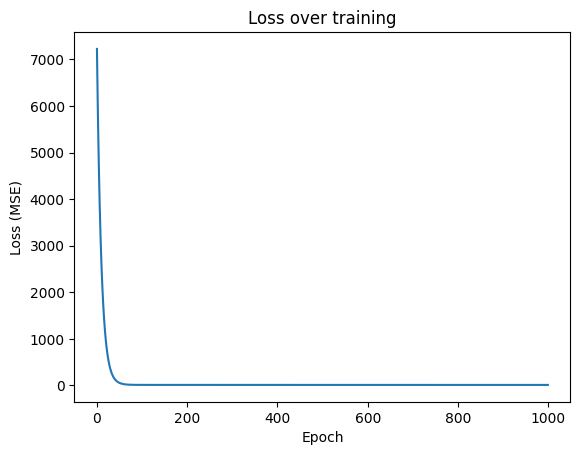

In [29]:
import matplotlib.pyplot as plt

plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Loss over training")
plt.show()


#Observations:
- initial error 6781 when model hasn't learned anything i.e w= 0 and b =0

- During 100-150 epochs ,loss dropped quickly

- Final loss - around 11 ,showing model learned relationship well

- Trainnig beyond 200 epoch gives only small improvements with this learning rate of 0.01